## Random Forest Model

In [19]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from sklearn.ensemble import RandomForestRegressor
import datetime as dt

In [14]:
# Step 2: Load Dataset (e.g., E-Commerce Dataset from Kaggle)
df = pd.read_csv('E-commerce_data.csv', encoding='ISO-8859-1')
df = df.dropna(subset=['CustomerID'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
# Create a total price column
# Quantity * UnitPrice = Total price for each item
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [15]:
# Define snapshot date as one day after the last invoice date
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Group by CustomerID to calculate Recency, Frequency, Monetary
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'TotalPrice': 'sum'                                       # Monetary (total spend)
})

# Rename columns appropriately
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

# Calculate Average Order Value (AOV)
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']

In [16]:
rfm.head(10)

,Recency,Frequency,Monetary,AOV
CustomerID,,,,
12346.0,326,2,0.00,0.000000
12347.0,2,7,4310.00,615.714286
12348.0,75,4,1797.24,449.310000
12349.0,19,1,1757.55,1757.550000
12350.0,310,1,334.40,334.400000
12352.0,36,11,1545.41,140.491818
12353.0,204,1,89.00,89.000000
12354.0,232,1,1079.40,1079.400000
12355.0,214,1,459.40,459.400000


In [21]:
# Step 5: Train-Test Split
X = rfm[['Recency', 'Frequency', 'AOV']]
y = rfm['Monetary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train the Model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Step 7: Predict and Evaluate
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

In [22]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 403.2581026400001
RMSE: 3736.4211366183276
R² Score: 0.8015076839901722


In [23]:
# Step 8: Predict LTV for All Customers
rfm['Predicted_LTV'] = model.predict(rfm[['Recency', 'Frequency', 'AOV']])
# Step 9: Segment Customers Based on LTV
rfm['Segment'] = pd.qcut(rfm['Predicted_LTV'], q=3, labels=['Low', 'Medium', 'High'])

In [24]:
rfm.head()

,Recency,Frequency,Monetary,AOV,Predicted_LTV,Segment
CustomerID,,,,,,
12346.0,326,2,0.00,0.000000,0.2907,Low
12347.0,2,7,4310.00,615.714286,4351.0256,High
12348.0,75,4,1797.24,449.310000,1795.2652,High
12349.0,19,1,1757.55,1757.550000,1764.9757,High
12350.0,310,1,334.40,334.400000,334.3752,Low


In [25]:
# Step 10: Save Final Predictions to CSV
rfm[['Predicted_LTV', 'Segment']].to_csv('ltv_predictions_By_RandomForest.csv')

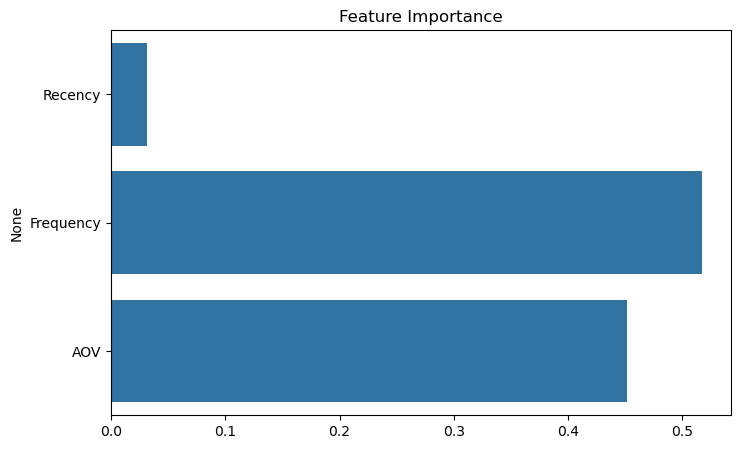

In [27]:
# Step 11: Visualizations
# Plot feature importances
importances = model.feature_importances_
features = X.columns
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.show()

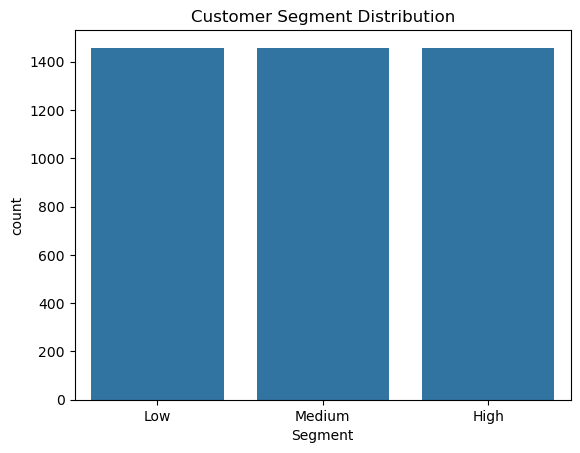

In [28]:
# Plot segment distribution
sns.countplot(data=rfm, x='Segment')
plt.title('Customer Segment Distribution')
plt.show()

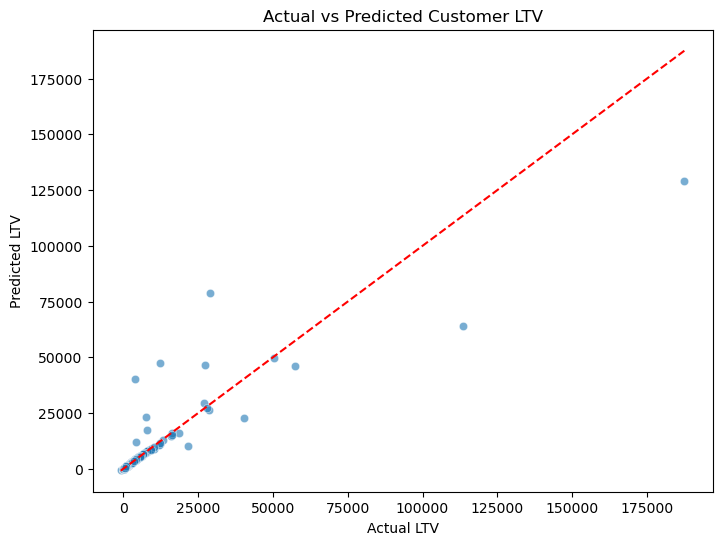

In [29]:
# Visualize Model Accuracy
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=preds, alpha=0.6)
plt.xlabel("Actual LTV")
plt.ylabel("Predicted LTV")
plt.title("Actual vs Predicted Customer LTV")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # Diagonal line
plt.show()